In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv(
    "../data/raw/train_FD001.txt",
    sep=r"\s+",
    header=None
)

In [3]:
train.shape

(20631, 26)

In [4]:
# Naming columns->>
columns = [
    "engine_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3"
]

In [5]:
number_of_sensor_columns = train.shape[1] - 5
sensor_columns = []

for i in range(1, 22):
    sensor_columns.append(f"sensor_{i}")

In [6]:
columns += sensor_columns
train.columns = columns

In [7]:
train.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [8]:
train["engine_id"].nunique()

100

In [9]:
train.groupby("engine_id")["cycle"].max()

engine_id
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

In [10]:
max_cycles = ( train.groupby("engine_id")["cycle"].max().reset_index())

In [11]:
max_cycles.columns = [ "engine_id" , "max_cycle"]

In [12]:
train = train.merge( max_cycles, on = "engine_id")
train["RUL"] = (train["max_cycle"] - train["cycle"])

In [13]:
train.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [14]:
engine_1 = train[ train["engine_id"] == 1]

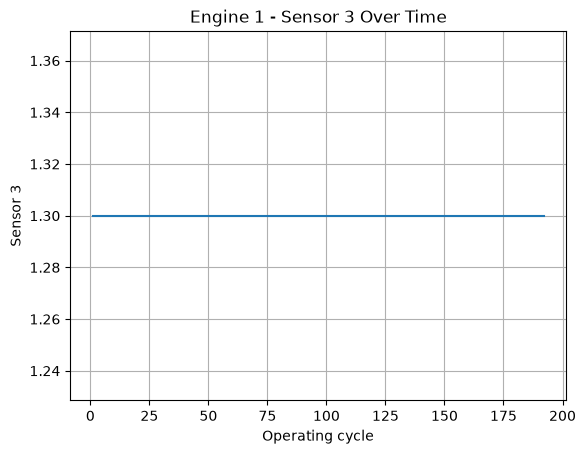

In [15]:
plt.plot(
    engine_1["cycle"],
    engine_1["sensor_10"]
)

plt.xlabel("Operating cycle")
plt.ylabel("Sensor 3")
plt.title("Engine 1 - Sensor 3 Over Time")
plt.grid()

plt.show()

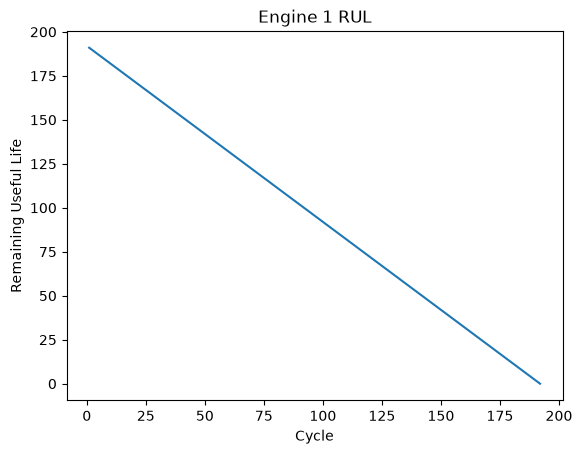

In [16]:
plt.plot(
    engine_1["cycle"],
    engine_1["RUL"]
)

plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life")
plt.title("Engine 1 RUL")

plt.show()